# CHASE DataLoader Test with `gt_dist` (Real Data)

`data/chase/` 실데이터(`img`, `gt`, `gt_dist`)를 직접 로드하여
이미지, 마스크, signed distance map의 로딩/배치/시각화를 검증합니다.

## Real CHASE Data (`data/chase`)

아래 셀은 임시(mock) 데이터가 아니라 리포지토리의 실제 `data/chase/` 파일을 사용합니다.
폴더 구조는 `img/`, `gt/`, `gt_dist/`를 기준으로 로드합니다.

In [20]:
from pathlib import Path

import numpy as np
import torch
from torch.utils.data import DataLoader, Dataset
import autorootcwd
from data_loader.GetDataset_CHASE import default_DRIVE_loader

data_root = Path('data/chase')
img_dir = data_root / 'img'
gt_dir = data_root / 'gt'
dist_dir = data_root / 'gt_dist'

assert img_dir.exists(), f'Missing: {img_dir}'
assert gt_dir.exists(), f'Missing: {gt_dir}'
assert dist_dir.exists(), f'Missing: {dist_dir}'

In [21]:
class RealCHASEWithSignedDist(Dataset):
    def __init__(self, data_root: Path):
        self.data_root = Path(data_root)
        self.img_dir = self.data_root / 'img'
        self.gt_dir = self.data_root / 'gt'
        self.dist_dir = self.data_root / 'gt_dist'

        self.samples = []
        for img_path in sorted(self.img_dir.glob('Image_*.jpg')):
            stem = img_path.stem  # e.g., Image_01L
            gt_path = self.gt_dir / f'{stem}_1stHO.png'
            dist_path = self.dist_dir / f'{stem}_1stHO_dist.npy'
            if gt_path.exists() and dist_path.exists():
                self.samples.append((img_path, gt_path, dist_path, stem))

        if len(self.samples) == 0:
            raise RuntimeError('No valid samples found in data/chase with matching gt and gt_dist .npy files.')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        img_path, gt_path, dist_path, name = self.samples[index]
        img, mask = default_DRIVE_loader(str(img_path), str(gt_path), train=False)
        img = torch.tensor(img, dtype=torch.float32)
        mask = torch.tensor(mask, dtype=torch.float32)
        gt_dist = torch.from_numpy(np.load(dist_path)).float()
        return img, mask, gt_dist, name

In [22]:
real_dataset = RealCHASEWithSignedDist(data_root)
print('real samples:', len(real_dataset))

img, mask, gt_dist, name = real_dataset[0]
print('name:', name)
print('img shape:', tuple(img.shape))
print('mask shape:', tuple(mask.shape))
print('gt_dist shape:', tuple(gt_dist.shape))

real_loader = DataLoader(real_dataset, batch_size=2, shuffle=False)
b_img, b_mask, b_dist, b_name = next(iter(real_loader))
print('batch img:', tuple(b_img.shape))
print('batch mask:', tuple(b_mask.shape))
print('batch gt_dist:', tuple(b_dist.shape))
print('batch names:', list(b_name))

real samples: 28
name: Image_01L
img shape: (3, 960, 960)
mask shape: (1, 960, 960)
gt_dist shape: (960, 999)
batch img: (2, 3, 960, 960)
batch mask: (2, 1, 960, 960)
batch gt_dist: (2, 960, 999)
batch names: ['Image_01L', 'Image_01R']


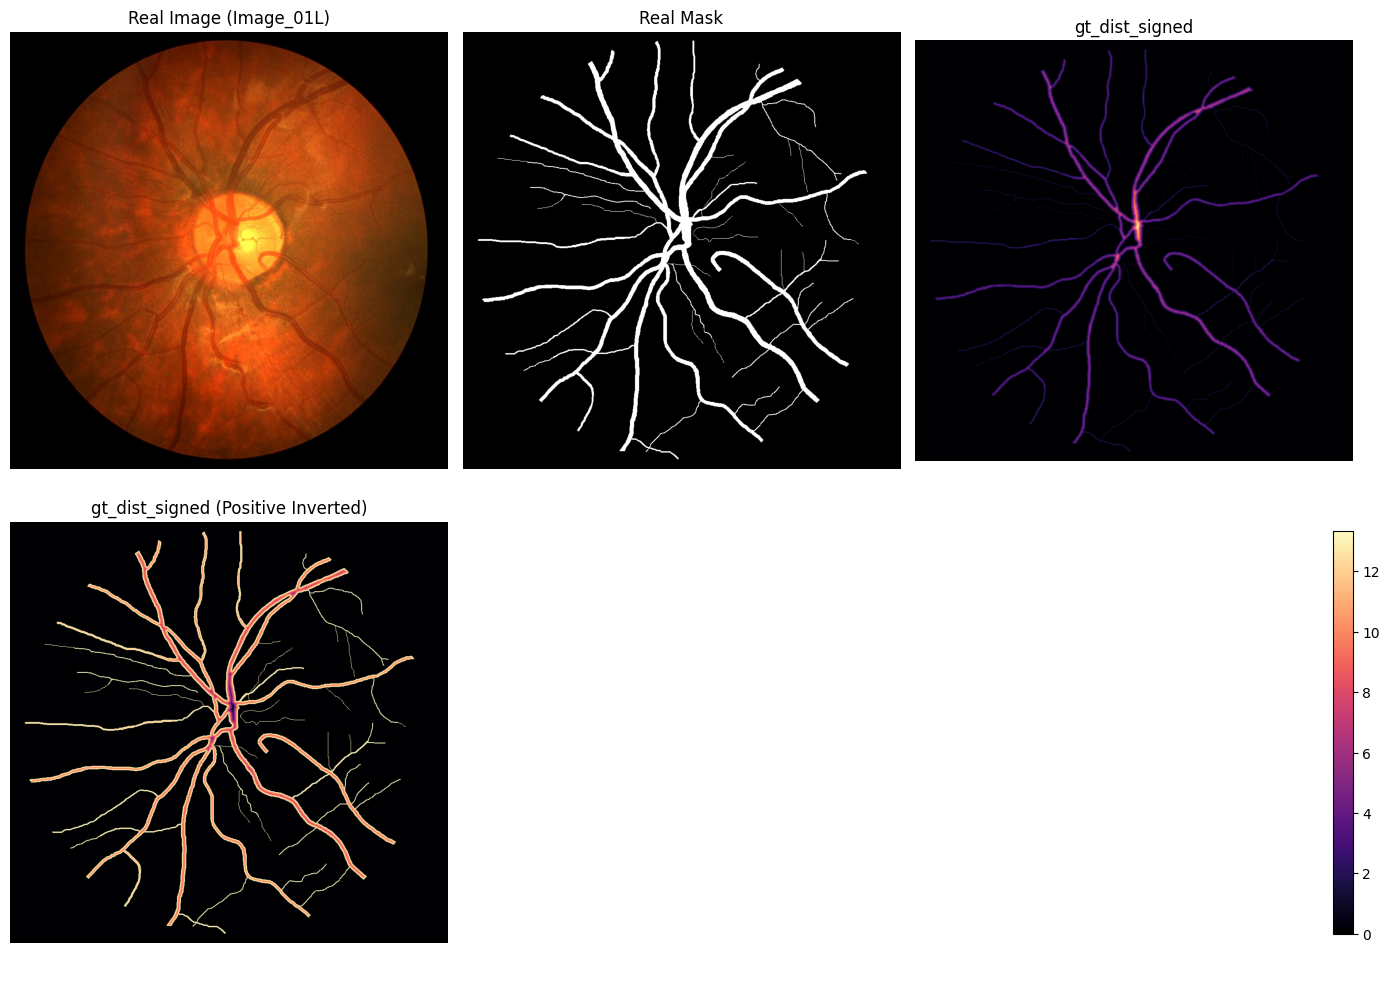

In [23]:
import matplotlib.pyplot as plt

img, mask, gt_dist, name = real_dataset[0]
img_np = img.permute(1, 2, 0).cpu().numpy()
img_np = img_np[..., ::-1]  # BGR -> RGB for correct visualization
img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min() + 1e-8)
mask_np = mask.squeeze(0).cpu().numpy()
dist_np = gt_dist.cpu().numpy()
dist_np_inv = np.zeros_like(dist_np)
dist_np_inv[dist_np > 0] = dist_np.max() - dist_np[dist_np > 0]

fig, axes = plt.subplots(2, 3, figsize=(14, 10))
axes[0, 0].imshow(img_np)
axes[0, 0].set_title(f'Real Image ({name})')
axes[0, 1].imshow(mask_np, cmap='gray')
axes[0, 1].set_title('Real Mask')
im = axes[0, 2].imshow(dist_np, cmap='magma')
axes[0, 2].set_title('gt_dist')
axes[1, 0].imshow(dist_np_inv, cmap='magma')
axes[1, 0].set_title(f'gt_dist (Positive Inverted)')
for ax in axes.flatten():
    ax.axis('off')
fig.colorbar(im, ax=axes[1, 2], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()